2.291132985265319e-19
2172552450466435.0
2172571793525843.5
[2.17255245e+15 2.17257418e+15 2.17259590e+15 ... 4.34506145e+15
 4.34508318e+15 4.34510490e+15]
[ 1 -1 -1 ... -1 -1 -1]


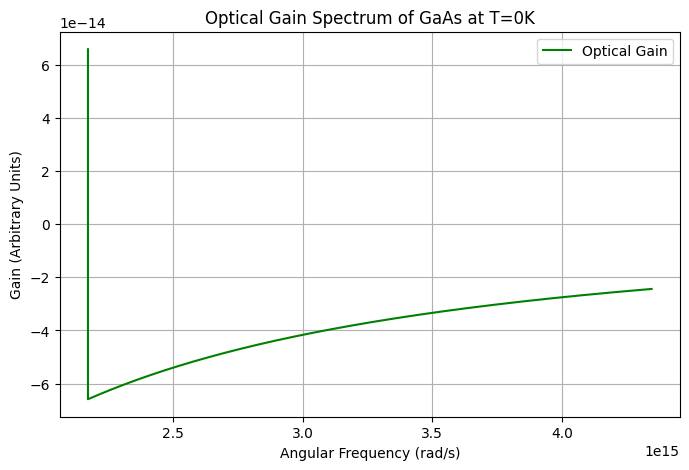

In [105]:
import numpy as np
from scipy.constants import e, hbar, m_e, c
import matplotlib.pyplot as plt

# Given parameters
c = 3e8  # Speed of light in m/s
n = 3.6  # Refractive index of GaAs
N_e = 3*10**18
N_h = N_e
E_G = 1.43*e
m_c = .07*m_e
m_h = .4*m_e

Diff = E_G+hbar**2/2*(3*np.pi**2*N_e)**(2/3)*(1/m_c+1/m_h)
print(Diff)
diff_w = Diff/hbar
print(E_G/hbar)
print(diff_w)
omega = np.linspace(E_G/hbar,E_G/hbar*2,100000)
print(omega)
E_photon = omega * hbar



prefactor = (c**2 / (8 * np.pi**2 * n**2)*10**-9) * ((2 * m_c * m_h) / (hbar * (m_c + m_h)))**(3/2)


def optical_gain(omega):
    E = omega*hbar 
    #step_factor2 = np.where(omega < E_G/hbar, 0, 1)
    step_factor = np.where(omega > diff_w,-1,1)
    print(step_factor)
    gain = prefactor * 1/(omega**2) * np.sqrt((2*np.pi*omega - E_G/hbar)) * step_factor #* step_factor2  # Apply step function
    return gain

gain_full = optical_gain(omega)

plt.figure(figsize=(8, 5))
plt.plot(omega, gain_full, label='Optical Gain', color='green')
plt.xlabel("Angular Frequency (rad/s)")
plt.ylabel("Gain (Arbitrary Units)")
plt.title("Optical Gain Spectrum of GaAs at T=0K")
plt.legend()
plt.grid()
plt.show()

In [42]:
import numpy as np
from scipy.integrate import quad
from scipy.constants import hbar, m_e, pi, e

# Define constants
E_C = 1e-19  # Lower limit of integration (in Joules, can be adjusted)
c = 1e-20  # A parameter (e.g., temperature, or a constant in the problem)
K = 300
T = 300
# Prefactor
prefactor = (1 / (2 * pi)) * (2 * m_e / hbar**2)**(3/2)
c = .0259

def integrand(u):
    return u**(1/2) / (np.exp((u-.005) / c) + 1)

result, error = quad(integrand, E_C, np.inf)

final_result = prefactor * result

print(f"Integral result: {final_result}")
print(f"Estimated error: {error}")
## Didn't work, computed value of 2.22e18 using online integral calculator 

Integral result: 1.0960648126594654e+54
Estimated error: 3.5721608279866424e-09


/var/folders/15/lp7t59857h50cjz_l1jdwrbw0000gn/T/ipykernel_41330/438386958.py:15: RuntimeWarning: overflow encountered in exp
  return u**(1/2) / (np.exp((u-.005) / c) + 1)
